In [1]:
# Iris 데이터셋 기반 통계분석 종합 실습
# 분석 목차:
#   1. 데이터 로딩 및 탐색
#   2. 상관분석 (Correlation Analysis)
#   3. t-test (독립표본 t검정)
#   4. ANOVA (일원분산분석)
#   5. PCA (주성분분석)
#   6. 군집분석 (K-Means Clustering)
#   7. 군집 프로파일링 (Cluster Profiling)

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [4]:
# 한글깨짐 해결, 원인:디폴트 영문글꼴==>한글글꼴
import matplotlib.pyplot as plt
import platform
if platform.system() == 'Windows': # W:대문자
    plt.rcParams['font.family'] = 'Malgun Gothic' # M,G:대문자, 중간에 스페이스 한칸
elif platform.system() == 'Darwin': # 맥OS, D:대문자
    plt.rcParams['font.family'] = 'AppleGothic'
else: # 리눅스
    plt.rcParams['font.family'] = 'NanumGothic'
# -(마이너스 기호) 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [5]:
from sklearn.datasets import load_iris

iris = load_iris()

# DataFrame 생성
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target
df['species_name'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

# 컬럼명 간소화
df.columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
              'species', 'species_name']

print("데이터 shape:", df.shape)
print()
df

데이터 shape: (150, 6)



,sepal_length,sepal_width,petal_length,petal_width,species,species_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,virginica
146,6.3,2.5,5.0,1.9,2,virginica
147,6.5,3.0,5.2,2.0,2,virginica
148,6.2,3.4,5.4,2.3,2,virginica


In [6]:
# 기초 통계량
df.describe().round(2)

,sepal_length,sepal_width,petal_length,petal_width,species
count,150.00,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20,1.00
std,0.83,0.44,1.77,0.76,0.82
min,4.30,2.00,1.00,0.10,0.00
25%,5.10,2.80,1.60,0.30,0.00
50%,5.80,3.00,4.35,1.30,1.00
75%,6.40,3.30,5.10,1.80,2.00
max,7.90,4.40,6.90,2.50,2.00


In [7]:
# 품종별 데이터 수 확인
df['species_name'].value_counts()

species_name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

In [8]:
# 품종별 기초 통계
df.groupby('species_name')[['sepal_length', 'sepal_width',
                             'petal_length', 'petal_width']].mean().round(2)

,sepal_length,sepal_width,petal_length,petal_width
species_name,,,,
setosa,5.01,3.43,1.46,0.25
versicolor,5.94,2.77,4.26,1.33
virginica,6.59,2.97,5.55,2.03


## 상관분석 (Correlation Analysis)
- 연속형 변수 간의 선형 관계를 파악
- 피어슨 상관계수: -1 ~ +1

In [9]:
# 수치형 변수만 선택
numeric_cols = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

# 피어슨 상관계수 행렬
corr_matrix = df[numeric_cols].corr().round(3)
print("=== 피어슨 상관계수 행렬 ===")
print(corr_matrix)

=== 피어슨 상관계수 행렬 ===
              sepal_length  sepal_width  petal_length  petal_width
sepal_length         1.000       -0.118         0.872        0.818
sepal_width         -0.118        1.000        -0.428       -0.366
petal_length         0.872       -0.428         1.000        0.963
petal_width          0.818       -0.366         0.963        1.000


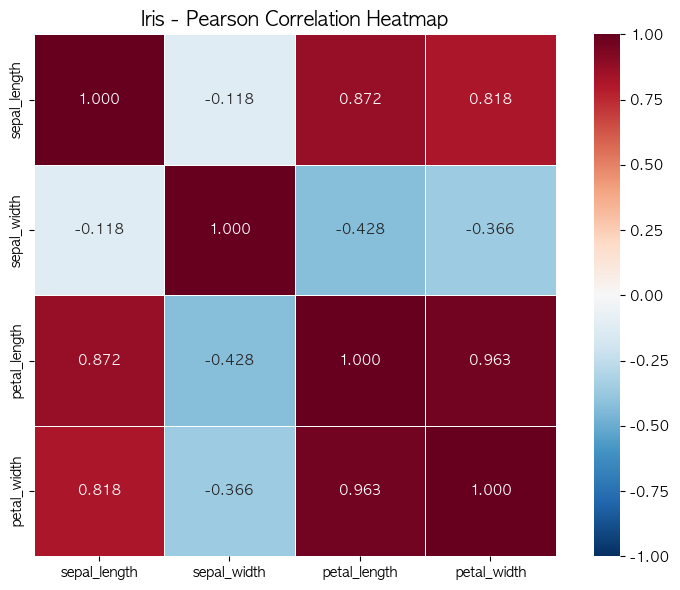

In [10]:
# 상관계수 히트맵
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, fmt='.3f', square=True,
            linewidths=0.5, linecolor='white')
plt.title('Iris - Pearson Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [11]:
# 개별 상관분석 (p-value 포함)
# 예: petal_length vs petal_width
r, p_value = stats.pearsonr(df['petal_length'], df['petal_width'])
print(f"petal_length vs petal_width")
print(f"  상관계수 (r) = {r:.4f}")
print(f"  p-value      = {p_value:.2e}")
print(f"  해석: {'유의미한 상관관계' if p_value < 0.05 else '유의미하지 않음'} (α=0.05)")

petal_length vs petal_width
  상관계수 (r) = 0.9629
  p-value      = 4.68e-86
  해석: 유의미한 상관관계 (α=0.05)


In [12]:
# 전체 변수 쌍의 상관계수 + p-value 표
print("=== 전체 변수 쌍별 상관분석 결과 ===")
print(f"{'변수1':<15} {'변수2':<15} {'r':>8} {'p-value':>12} {'유의성':>6}")
print("-" * 60)

for i in range(len(numeric_cols)):
    for j in range(i+1, len(numeric_cols)):
        r, p = stats.pearsonr(df[numeric_cols[i]], df[numeric_cols[j]])
        sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
        print(f"{numeric_cols[i]:<15} {numeric_cols[j]:<15} {r:>8.4f} {p:>12.2e} {sig:>6}")

=== 전체 변수 쌍별 상관분석 결과 ===
변수1             변수2                    r      p-value    유의성
------------------------------------------------------------
sepal_length    sepal_width      -0.1176     1.52e-01     ns
sepal_length    petal_length      0.8718     1.04e-47    ***
sepal_length    petal_width       0.8179     2.33e-37    ***
sepal_width     petal_length     -0.4284     4.51e-08    ***
sepal_width     petal_width      -0.3661     4.07e-06    ***
petal_length    petal_width       0.9629     4.68e-86    ***


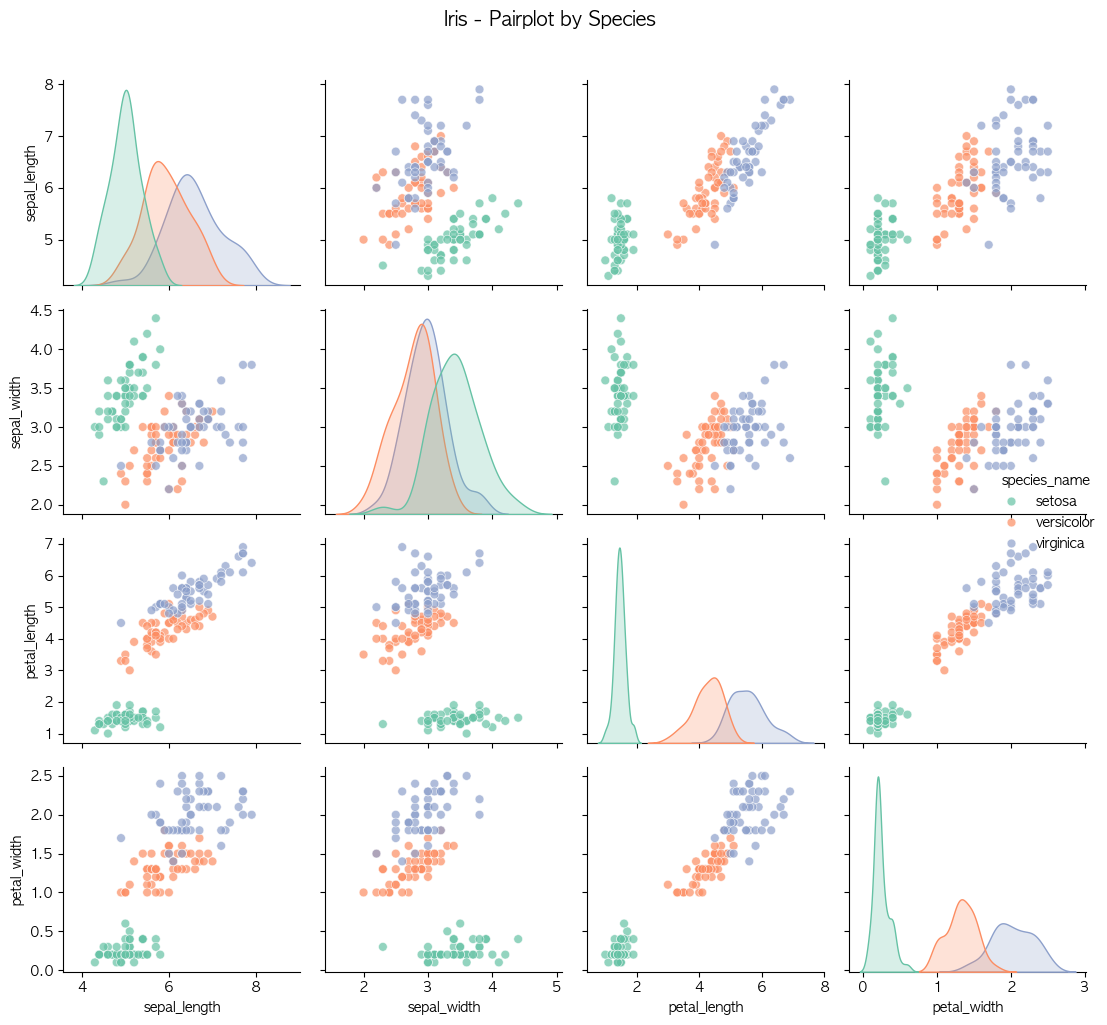

In [13]:
# 산점도 매트릭스 (pairplot)
sns.pairplot(df, vars=numeric_cols, hue='species_name',
             palette='Set2', diag_kind='kde', height=2.5,
             plot_kws={'alpha': 0.7, 's': 40})
plt.suptitle('Iris - Pairplot by Species', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## t-test (독립표본 t검정)
- 두 그룹의 평균 차이가 통계적으로 유의미한지 검정
- 여기서는 setosa vs versicolor 비교

In [14]:
# 두 그룹 분리
setosa = df[df['species_name'] == 'setosa']
versicolor = df[df['species_name'] == 'versicolor']

print(f"setosa 표본 수: {len(setosa)}")
print(f"versicolor 표본 수: {len(versicolor)}")

# %%
# 정규성 검정 (Shapiro-Wilk)
print("=== 정규성 검정 (Shapiro-Wilk) ===")
print(f"{'변수':<15} {'setosa W':>10} {'p-value':>10} {'versicolor W':>13} {'p-value':>10}")
print("-" * 62)

for col in numeric_cols:
    w1, p1 = stats.shapiro(setosa[col])
    w2, p2 = stats.shapiro(versicolor[col])
    print(f"{col:<15} {w1:>10.4f} {p1:>10.4f} {w2:>13.4f} {p2:>10.4f}")

setosa 표본 수: 50
versicolor 표본 수: 50
=== 정규성 검정 (Shapiro-Wilk) ===
변수                setosa W    p-value  versicolor W    p-value
--------------------------------------------------------------
sepal_length        0.9777     0.4595        0.9778     0.4647
sepal_width         0.9717     0.2715        0.9741     0.3380
petal_length        0.9550     0.0548        0.9660     0.1585
petal_width         0.7998     0.0000        0.9476     0.0273


In [15]:
# 등분산 검정 (Levene's test)
print("=== 등분산 검정 (Levene's Test) ===")
print(f"{'변수':<15} {'F-stat':>10} {'p-value':>10} {'등분산':>8}")
print("-" * 48)

for col in numeric_cols:
    stat, p = stats.levene(setosa[col], versicolor[col])
    equal_var = "Yes" if p >= 0.05 else "No"
    print(f"{col:<15} {stat:>10.4f} {p:>10.4f} {equal_var:>8}")

=== 등분산 검정 (Levene's Test) ===
변수                  F-stat    p-value      등분산
------------------------------------------------
sepal_length        8.1727     0.0052       No
sepal_width         0.5910     0.4439      Yes
petal_length       30.4995     0.0000       No
petal_width        15.8582     0.0001       No


In [16]:
# 독립표본 t-test 실행
print("=== 독립표본 t-test: setosa vs versicolor ===")
print(f"{'변수':<15} {'setosa 평균':>12} {'versi 평균':>12} {'t-stat':>10} {'p-value':>12} {'결론':>8}")
print("-" * 72)

for col in numeric_cols:
    # 등분산 여부 확인 후 적절한 t-test 수행
    _, levene_p = stats.levene(setosa[col], versicolor[col])
    equal_var = levene_p >= 0.05

    t_stat, p_value = stats.ttest_ind(setosa[col], versicolor[col],
                                       equal_var=equal_var)
    conclusion = "기각" if p_value < 0.05 else "채택"
    print(f"{col:<15} {setosa[col].mean():>12.2f} {versicolor[col].mean():>12.2f} "
          f"{t_stat:>10.4f} {p_value:>12.2e} {conclusion:>8}")

print()
print("* 기각 = 두 그룹의 평균 차이가 유의미함 (α=0.05)")

=== 독립표본 t-test: setosa vs versicolor ===
변수                 setosa 평균     versi 평균     t-stat      p-value       결론
------------------------------------------------------------------------
sepal_length            5.01         5.94   -10.5210     3.75e-17       기각
sepal_width             3.43         2.77     9.4550     1.85e-15       기각
petal_length            1.46         4.26   -39.4927     9.93e-46       기각
petal_width             0.25         1.33   -34.0803     2.72e-47       기각

* 기각 = 두 그룹의 평균 차이가 유의미함 (α=0.05)


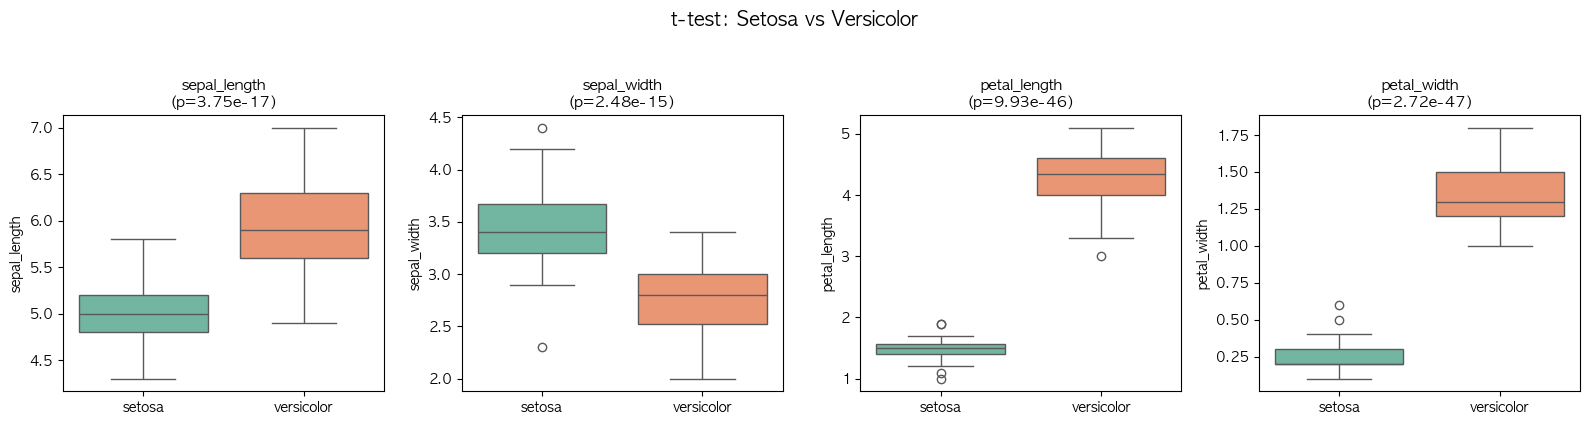

In [17]:
# t-test 시각화: 박스플롯
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

two_species = df[df['species_name'].isin(['setosa', 'versicolor'])]

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=two_species, x='species_name', y=col,
                palette='Set2', ax=axes[i])
    # p-value 표시
    _, p_val = stats.ttest_ind(setosa[col], versicolor[col], equal_var=False)
    axes[i].set_title(f'{col}\n(p={p_val:.2e})', fontsize=11)
    axes[i].set_xlabel('')

plt.suptitle('t-test: Setosa vs Versicolor', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

## ANOVA (일원분산분석)
- 3개 이상 그룹의 평균 차이를 검정
- 사후검정(Post-hoc): Tukey HSD

In [18]:
# 일원분산분석 (One-way ANOVA)
print("=== 일원분산분석 (One-way ANOVA) ===")
print("3개 품종(setosa, versicolor, virginica)의 평균 차이 검정")
print()
print(f"{'변수':<15} {'F-stat':>10} {'p-value':>12} {'결론':>10}")
print("-" * 50)

groups = [df[df['species_name'] == s] for s in ['setosa', 'versicolor', 'virginica']]

for col in numeric_cols:
    f_stat, p_value = stats.f_oneway(groups[0][col], groups[1][col], groups[2][col])
    conclusion = "유의미" if p_value < 0.05 else "유의미하지 않음"
    print(f"{col:<15} {f_stat:>10.4f} {p_value:>12.2e} {conclusion:>10}")

print()
print("* 귀무가설(H0): 세 그룹의 평균이 동일하다")
print("* p < 0.05이면 최소 하나의 그룹 평균이 다르다고 결론")

=== 일원분산분석 (One-way ANOVA) ===
3개 품종(setosa, versicolor, virginica)의 평균 차이 검정

변수                  F-stat      p-value         결론
--------------------------------------------------
sepal_length      119.2645     1.67e-31        유의미
sepal_width        49.1600     4.49e-17        유의미
petal_length     1180.1612     2.86e-91        유의미
petal_width       960.0071     4.17e-85        유의미

* 귀무가설(H0): 세 그룹의 평균이 동일하다
* p < 0.05이면 최소 하나의 그룹 평균이 다르다고 결론


In [19]:
try:
    import statsmodels
except:
    # ! pip install statsmodels
    %pip install statsmodels
# 노트북 환경에서는 !보다 % 기호를 쓰는 것이 훨씬 정확합니다.
# !pip은 시스템 전체에 깔려고 시도하지만, %pip은 현재 여러분이 쓰고 있는 이 노트북의 환경에 정확히 설치해 줍니다.

In [20]:
# 사후검정 (Tukey HSD)
from statsmodels.stats.multicomp import pairwise_tukeyhsd

print("=== 사후검정: Tukey HSD ===")
print()

for col in numeric_cols:
    print(f"--- {col} ---")
    tukey = pairwise_tukeyhsd(df[col], df['species_name'], alpha=0.05)
    print(tukey)
    print()

=== 사후검정: Tukey HSD ===

--- sepal_length ---
   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
  group1     group2   meandiff p-adj lower  upper  reject
---------------------------------------------------------
    setosa versicolor     0.93   0.0 0.6862 1.1738   True
    setosa  virginica    1.582   0.0 1.3382 1.8258   True
versicolor  virginica    0.652   0.0 0.4082 0.8958   True
---------------------------------------------------------

--- sepal_width ---
    Multiple Comparison of Means - Tukey HSD, FWER=0.05     
  group1     group2   meandiff p-adj   lower   upper  reject
------------------------------------------------------------
    setosa versicolor   -0.658    0.0 -0.8189 -0.4971   True
    setosa  virginica   -0.454    0.0 -0.6149 -0.2931   True
versicolor  virginica    0.204 0.0088  0.0431  0.3649   True
------------------------------------------------------------

--- petal_length ---
   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
  group1     group2 

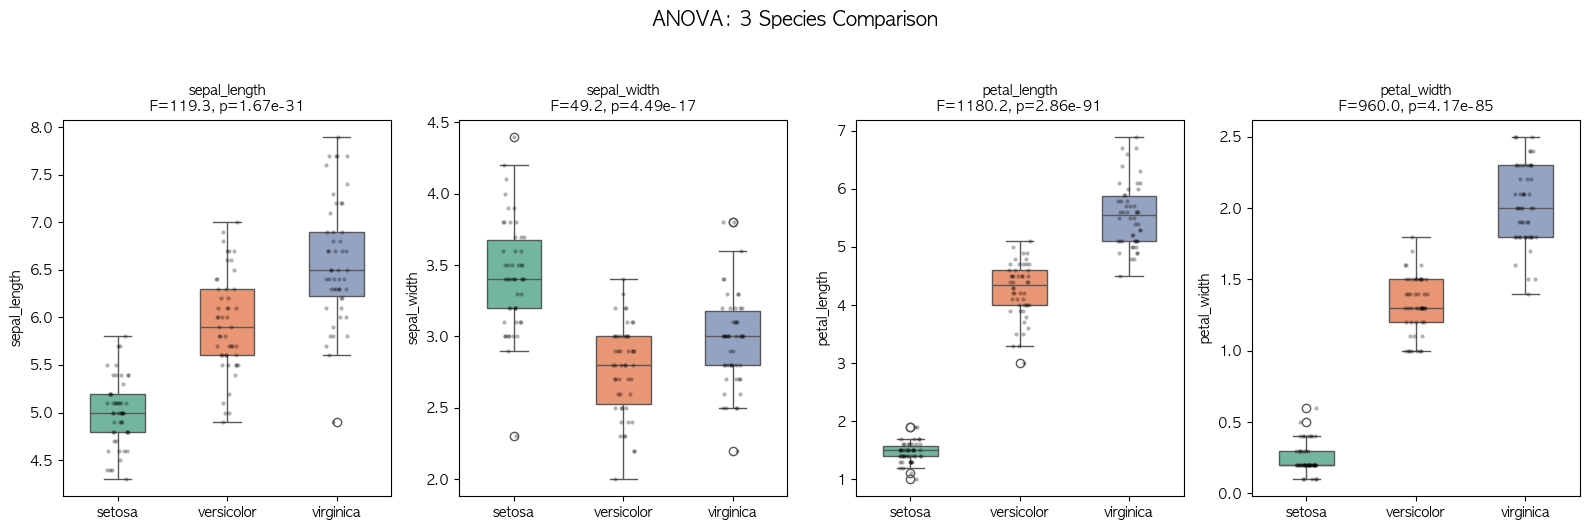

In [21]:
# ANOVA 시각화: 박스플롯 + 스트립플롯
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, x='species_name', y=col,
                palette='Set2', ax=axes[i], width=0.5)
    sns.stripplot(data=df, x='species_name', y=col,
                  color='black', alpha=0.3, size=3, ax=axes[i])
    # F-stat, p-value 표시
    f_stat, p_val = stats.f_oneway(groups[0][col], groups[1][col], groups[2][col])
    axes[i].set_title(f'{col}\nF={f_stat:.1f}, p={p_val:.2e}', fontsize=10)
    axes[i].set_xlabel('')

plt.suptitle('ANOVA: 3 Species Comparison', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

## PCA (주성분분석)
- 4개 변수를 2개 주성분으로 차원 축소
- 분산 설명력(explained variance ratio) 확인

In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 표준화 (PCA 전 필수)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[numeric_cols])

print("표준화 전 평균:", df[numeric_cols].mean().values.round(2))
print("표준화 후 평균:", X_scaled.mean(axis=0).round(2))
print("표준화 후 표준편차:", X_scaled.std(axis=0).round(2))

표준화 전 평균: [5.84 3.06 3.76 1.2 ]
표준화 후 평균: [-0. -0. -0. -0.]
표준화 후 표준편차: [1. 1. 1. 1.]


In [23]:
# PCA 수행 (전체 성분)
pca_full = PCA()
pca_full.fit(X_scaled)

print("=== PCA 분산 설명력 ===")
print(f"{'주성분':<8} {'설명력':>8} {'누적 설명력':>10}")
print("-" * 30)
# 각 주성분(PC1, PC2...)이 전체 데이터의 정보를 얼마나(몇 %) 가지고 있는지 누적 합계 얻기
cumsum = np.cumsum(pca_full.explained_variance_ratio_)

for i, (var, cum) in enumerate(zip(pca_full.explained_variance_ratio_, cumsum)):
    print(f"PC{i+1:<5} {var:>8.4f} {cum:>10.4f}")

=== PCA 분산 설명력 ===
주성분           설명력     누적 설명력
------------------------------
PC1       0.7296     0.7296
PC2       0.2285     0.9581
PC3       0.0367     0.9948
PC4       0.0052     1.0000


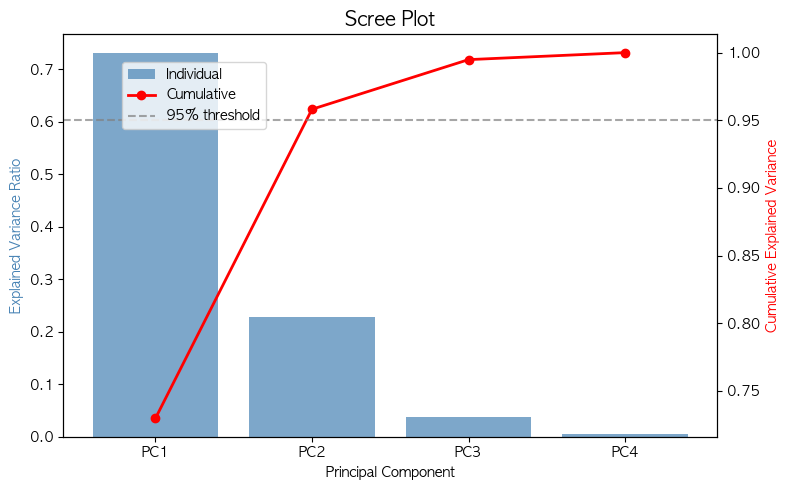

In [24]:
# 스크리 플롯 (Scree Plot)
fig, ax1 = plt.subplots(figsize=(8, 5))

x = range(1, 5)
ax1.bar(x, pca_full.explained_variance_ratio_, color='steelblue', alpha=0.7, label='Individual')
ax1.set_ylabel('Explained Variance Ratio', color='steelblue')
ax1.set_xlabel('Principal Component')
ax1.set_xticks(x)
ax1.set_xticklabels(['PC1', 'PC2', 'PC3', 'PC4'])

ax2 = ax1.twinx()
ax2.plot(x, cumsum, 'ro-', linewidth=2, label='Cumulative')
ax2.set_ylabel('Cumulative Explained Variance', color='red')
ax2.axhline(y=0.95, color='gray', linestyle='--', alpha=0.7, label='95% threshold')

fig.legend(loc='upper left', bbox_to_anchor=(0.15, 0.88))
plt.title('Scree Plot', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [25]:
# PCA 2차원 변환
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['species_name'] = df['species_name']

print(f"PC1 설명력: {pca.explained_variance_ratio_[0]:.4f} ({pca.explained_variance_ratio_[0]*100:.1f}%)")
print(f"PC2 설명력: {pca.explained_variance_ratio_[1]:.4f} ({pca.explained_variance_ratio_[1]*100:.1f}%)")
print(f"누적 설명력: {sum(pca.explained_variance_ratio_)*100:.1f}%")

PC1 설명력: 0.7296 (73.0%)
PC2 설명력: 0.2285 (22.9%)
누적 설명력: 95.8%


In [26]:
# 주성분 적재값 (Loading)
loading = pd.DataFrame(pca.components_.T,
                        columns=['PC1', 'PC2'],
                        index=numeric_cols)
print("=== 주성분 적재값 (Loading) ===")
print(loading.round(4))
print()
print("해석: 절대값이 클수록 해당 변수가 주성분에 기여하는 비중이 큼")

=== 주성분 적재값 (Loading) ===
                 PC1     PC2
sepal_length  0.5211  0.3774
sepal_width  -0.2693  0.9233
petal_length  0.5804  0.0245
petal_width   0.5649  0.0669

해석: 절대값이 클수록 해당 변수가 주성분에 기여하는 비중이 큼


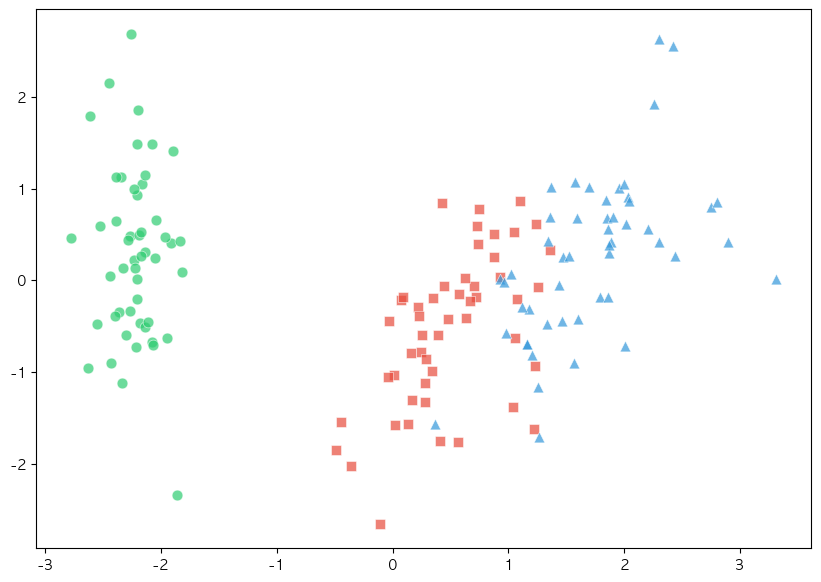

In [27]:
# PCA 산점도
plt.figure(figsize=(10, 7))
species_list = ['setosa', 'versicolor', 'virginica']
colors = ['#2ecc71', '#e74c3c', '#3498db']
markers = ['o', 's', '^']

for sp, color, marker in zip(species_list, colors, markers):
    mask = df_pca['species_name'] == sp
    plt.scatter(df_pca.loc[mask, 'PC1'], df_pca.loc[mask, 'PC2'],
                c=color, marker=marker, s=60, alpha=0.7,
                edgecolors='white', linewidths=0.5, label=sp)

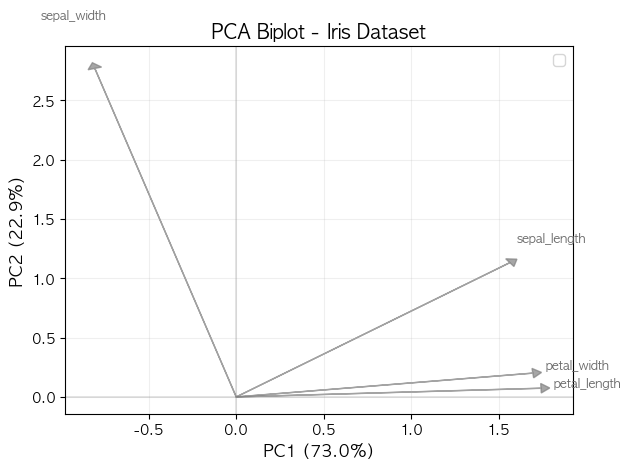

In [28]:
# 적재 벡터(Biplot)
scale = 3
for i, col in enumerate(numeric_cols):
    plt.arrow(0, 0, loading.iloc[i, 0]*scale, loading.iloc[i, 1]*scale,
              head_width=0.08, head_length=0.05, fc='gray', ec='gray', alpha=0.7)
    plt.text(loading.iloc[i, 0]*scale*1.15, loading.iloc[i, 1]*scale*1.15,
             col, fontsize=9, ha='center', color='dimgray')

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
plt.title('PCA Biplot - Iris Dataset', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.axhline(y=0, color='gray', linestyle='-', linewidth=0.3)
plt.axvline(x=0, color='gray', linestyle='-', linewidth=0.3)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 군집분석 (K-Means Clustering)
- 비지도학습: 레이블 없이 자연적인 그룹 탐색
- 엘보우 방법으로 최적 k 결정

In [29]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

# 엘보우 방법 (Elbow Method)
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, km.labels_))

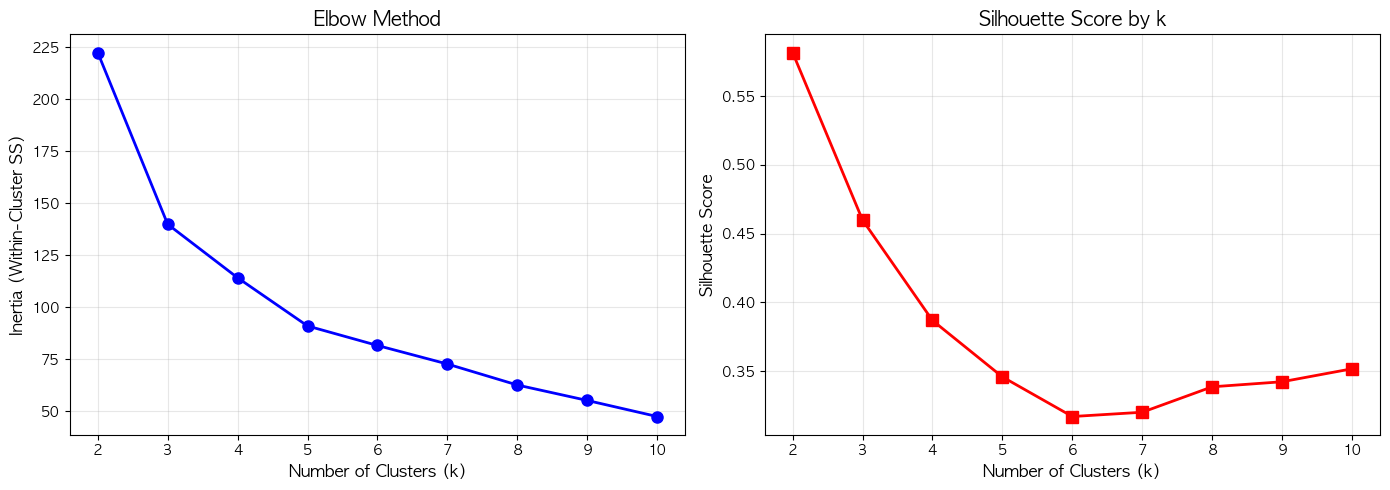

실루엣 점수 최대: k=2, score=0.5818


In [30]:
# 엘보우 플롯 + 실루엣 점수
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Clusters (k)', fontsize=12)
ax1.set_ylabel('Inertia (Within-Cluster SS)', fontsize=12)
ax1.set_title('Elbow Method', fontsize=14, fontweight='bold')
ax1.set_xticks(list(K_range))
ax1.grid(alpha=0.3)

ax2.plot(K_range, silhouette_scores, 'rs-', linewidth=2, markersize=8)
ax2.set_xlabel('Number of Clusters (k)', fontsize=12)
ax2.set_ylabel('Silhouette Score', fontsize=12)
ax2.set_title('Silhouette Score by k', fontsize=14, fontweight='bold')
ax2.set_xticks(list(K_range))
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"실루엣 점수 최대: k={K_range[np.argmax(silhouette_scores)]}, "
      f"score={max(silhouette_scores):.4f}")

In [31]:
# K-Means (k=3) 실행
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

print("=== K-Means 군집 결과 (k=3) ===")
print(f"실루엣 점수: {silhouette_score(X_scaled, df['cluster']):.4f}")
print()
print("군집별 데이터 수:")
print(df['cluster'].value_counts().sort_index())

=== K-Means 군집 결과 (k=3) ===
실루엣 점수: 0.4599

군집별 데이터 수:
cluster
0    53
1    50
2    47
Name: count, dtype: int64


In [32]:
# 군집 vs 실제 품종 교차표
print("=== 군집 vs 실제 품종 교차표 ===")
cross_tab = pd.crosstab(df['cluster'], df['species_name'],
                         margins=True, margins_name='합계')
print(cross_tab)
print()
print("해석: 군집이 실제 품종과 얼마나 일치하는지 확인")

=== 군집 vs 실제 품종 교차표 ===
species_name  setosa  versicolor  virginica   합계
cluster                                         
0                  0          39         14   53
1                 50           0          0   50
2                  0          11         36   47
합계                50          50         50  150

해석: 군집이 실제 품종과 얼마나 일치하는지 확인


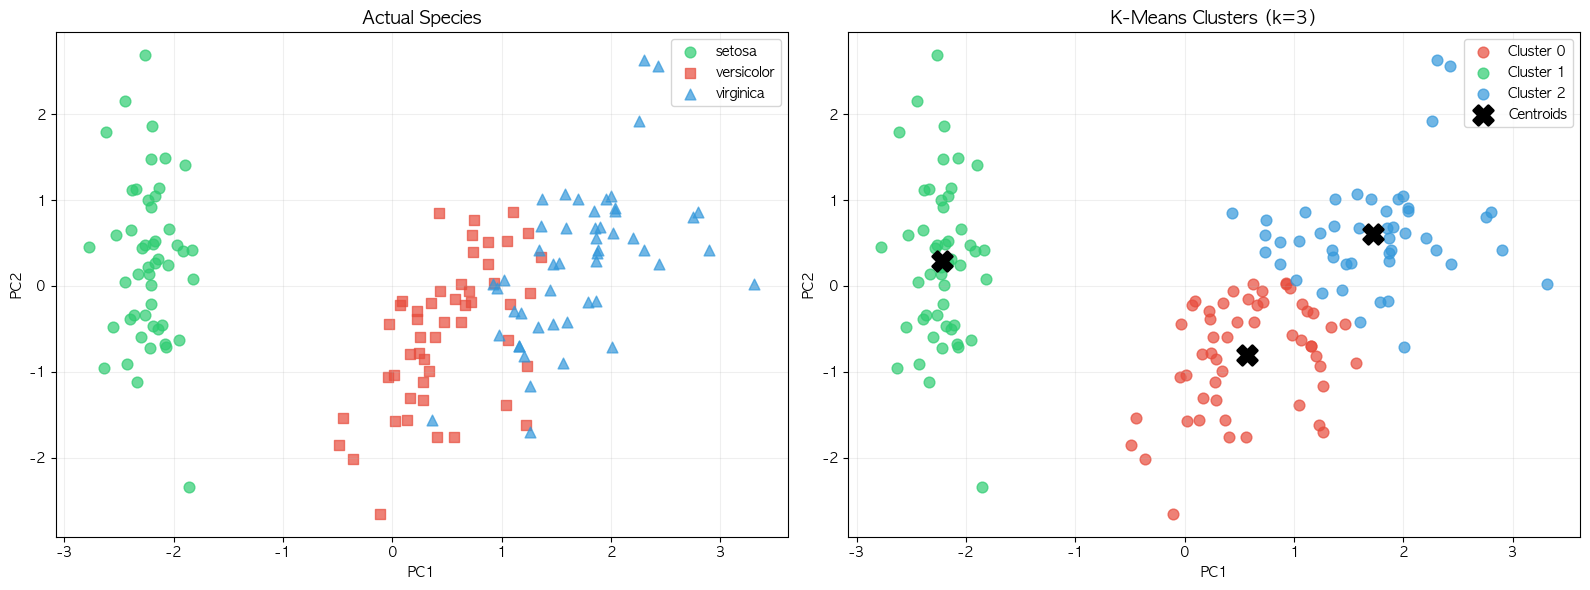

In [33]:
# 군집 시각화 (PCA 공간)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 실제 품종
for sp, color, marker in zip(species_list, colors, markers):
    mask = df['species_name'] == sp
    ax1.scatter(df_pca.loc[mask, 'PC1'], df_pca.loc[mask, 'PC2'],
                c=color, marker=marker, s=60, alpha=0.7, label=sp)
ax1.set_title('Actual Species', fontsize=13, fontweight='bold')
ax1.set_xlabel('PC1'); ax1.set_ylabel('PC2')
ax1.legend()
ax1.grid(alpha=0.2)

# K-Means 군집
cluster_colors = ['#e74c3c', '#2ecc71', '#3498db']
for cl in range(3):
    mask = df['cluster'] == cl
    ax2.scatter(df_pca.loc[mask, 'PC1'], df_pca.loc[mask, 'PC2'],
                c=cluster_colors[cl], s=60, alpha=0.7, label=f'Cluster {cl}')

# 중심점 표시
centers_pca = pca.transform(kmeans.cluster_centers_)
ax2.scatter(centers_pca[:, 0], centers_pca[:, 1],
            c='black', marker='X', s=200, linewidths=2, label='Centroids')
ax2.set_title('K-Means Clusters (k=3)', fontsize=13, fontweight='bold')
ax2.set_xlabel('PC1'); ax2.set_ylabel('PC2')
ax2.legend()
ax2.grid(alpha=0.2)

plt.tight_layout()
plt.show()

## 군집 프로파일링 (Cluster Profiling)
- 각 군집의 특성을 분석하고 해석
- 군집별 평균, 표준편차 비교
- 레이더 차트로 시각화

In [34]:
# 군집별 기술통계
print("=== 군집별 평균 ===")
cluster_profile = df.groupby('cluster')[numeric_cols].mean().round(2)
print(cluster_profile)
print()

print("=== 군집별 표준편차 ===")
cluster_std = df.groupby('cluster')[numeric_cols].std().round(2)
print(cluster_std)

=== 군집별 평균 ===
         sepal_length  sepal_width  petal_length  petal_width
cluster                                                      
0                5.80         2.67          4.37         1.41
1                5.01         3.43          1.46         0.25
2                6.78         3.10          5.51         1.97

=== 군집별 표준편차 ===
         sepal_length  sepal_width  petal_length  petal_width
cluster                                                      
0                0.41         0.25          0.56         0.31
1                0.35         0.38          0.17         0.11
2                0.49         0.26          0.64         0.33


In [35]:
# 전체 평균 대비 군집 특성 (z-score 방식)
overall_mean = df[numeric_cols].mean()
overall_std = df[numeric_cols].std()

profile_z = (cluster_profile - overall_mean) / overall_std
print("=== 군집별 프로파일 (전체 평균 대비 z-score) ===")
print(profile_z.round(3))
print()
print("해석: 양수 = 평균보다 높음, 음수 = 평균보다 낮음")

=== 군집별 프로파일 (전체 평균 대비 z-score) ===
         sepal_length  sepal_width  petal_length  petal_width
cluster                                                      
0              -0.052       -0.889         0.347        0.276
1              -1.006        0.855        -1.302       -1.245
2               1.131        0.098         0.992        1.011

해석: 양수 = 평균보다 높음, 음수 = 평균보다 낮음


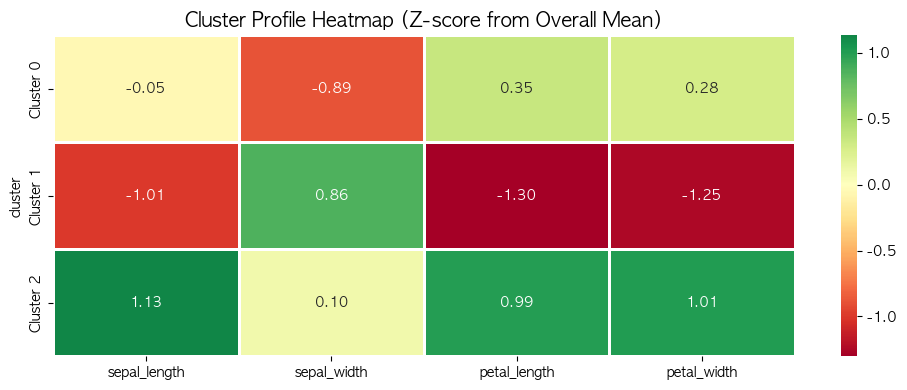

In [36]:
# 프로파일 히트맵
plt.figure(figsize=(10, 4))
sns.heatmap(profile_z, annot=True, cmap='RdYlGn', center=0,
            fmt='.2f', linewidths=1, linecolor='white',
            xticklabels=numeric_cols,
            yticklabels=[f'Cluster {i}' for i in range(3)])
plt.title('Cluster Profile Heatmap (Z-score from Overall Mean)',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

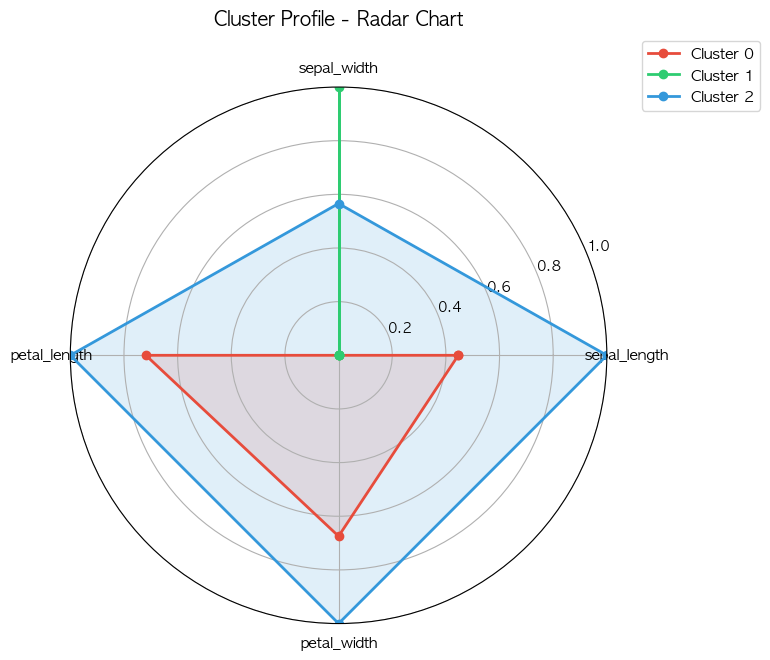

In [37]:
# 레이더 차트 (Spider Chart)
from matplotlib.patches import FancyBboxPatch

# Min-Max 정규화 (0~1 범위, 레이더 차트용)
from sklearn.preprocessing import MinMaxScaler
mms = MinMaxScaler()
profile_norm = pd.DataFrame(
    mms.fit_transform(cluster_profile),
    columns=numeric_cols,
    index=cluster_profile.index
)

categories = numeric_cols
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # 닫기

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

cluster_colors_radar = ['#e74c3c', '#2ecc71', '#3498db']
for cl in range(3):
    values = profile_norm.iloc[cl].tolist()
    values += values[:1]  # 닫기
    ax.plot(angles, values, 'o-', linewidth=2, color=cluster_colors_radar[cl],
            label=f'Cluster {cl}')
    ax.fill(angles, values, alpha=0.15, color=cluster_colors_radar[cl])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylim(0, 1)
ax.set_title('Cluster Profile - Radar Chart', fontsize=14, fontweight='bold', y=1.1)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)
plt.tight_layout()
plt.show()

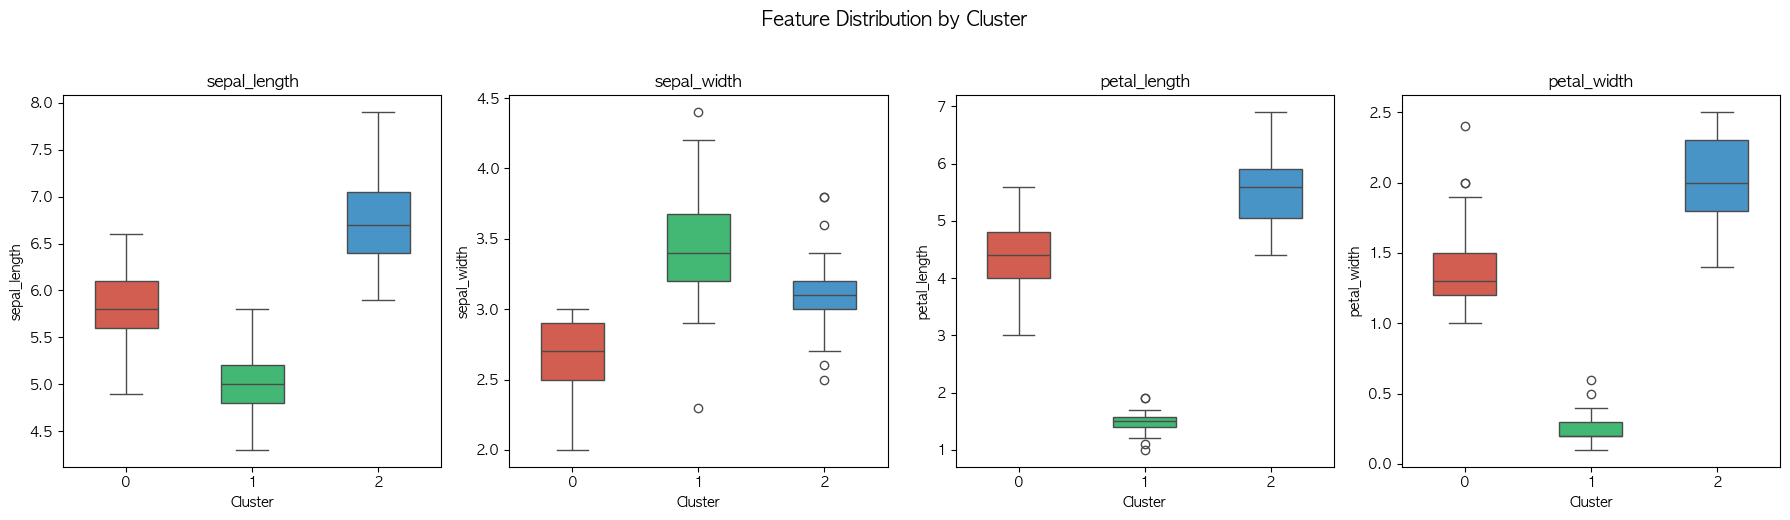

In [38]:
# 군집별 박스플롯 비교
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, x='cluster', y=col,
                palette=cluster_colors_radar, ax=axes[i], width=0.5)
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Cluster')

plt.suptitle('Feature Distribution by Cluster', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

In [39]:
# 최종 프로파일 요약
print("=" * 70)
print("           최종 군집 프로파일 요약")
print("=" * 70)

for cl in range(3):
    dominant_species = df[df['cluster'] == cl]['species_name'].mode()[0]
    n = len(df[df['cluster'] == cl])
    print(f"\n【 Cluster {cl} 】 (n={n}, 주요 품종: {dominant_species})")
    print("-" * 50)
    for col in numeric_cols:
        mean_val = cluster_profile.loc[cl, col]
        z_val = profile_z.loc[cl, col]
        level = "↑ 높음" if z_val > 0.5 else "↓ 낮음" if z_val < -0.5 else "→ 보통"
        print(f"  {col:<15}: {mean_val:>6.2f}  (z={z_val:>6.3f}, {level})")

print()
print("=" * 70)
print("분석 완료!")
print("=" * 70)

           최종 군집 프로파일 요약

【 Cluster 0 】 (n=53, 주요 품종: versicolor)
--------------------------------------------------
  sepal_length   :   5.80  (z=-0.052, → 보통)
  sepal_width    :   2.67  (z=-0.889, ↓ 낮음)
  petal_length   :   4.37  (z= 0.347, → 보통)
  petal_width    :   1.41  (z= 0.276, → 보통)

【 Cluster 1 】 (n=50, 주요 품종: setosa)
--------------------------------------------------
  sepal_length   :   5.01  (z=-1.006, ↓ 낮음)
  sepal_width    :   3.43  (z= 0.855, ↑ 높음)
  petal_length   :   1.46  (z=-1.302, ↓ 낮음)
  petal_width    :   0.25  (z=-1.245, ↓ 낮음)

【 Cluster 2 】 (n=47, 주요 품종: virginica)
--------------------------------------------------
  sepal_length   :   6.78  (z= 1.131, ↑ 높음)
  sepal_width    :   3.10  (z= 0.098, → 보통)
  petal_length   :   5.51  (z= 0.992, ↑ 높음)
  petal_width    :   1.97  (z= 1.011, ↑ 높음)

분석 완료!


In [40]:
# end